# Day 1: LULC Data Exploration (EuroSAT)
This notebook covers the initial exploratory data analysis of the EuroSAT dataset, focusing on class distribution, spectral signatures, and spectral indices.

In [1]:
import os
import sys
import ssl
import zipfile
import urllib.request
import subprocess
from pathlib import Path

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    DATA_DIR = Path('/content/data/processed')
    FIGURES_DIR = Path('/content/report/figures')
else:
    DATA_DIR = Path('../data/processed')
    FIGURES_DIR = Path('../report/figures')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def _safe_remove(path):
    if os.path.exists(path):
        os.remove(path)


def _download_urllib(url, out_path):
    urllib.request.urlretrieve(url, out_path)


def _download_urllib_with_certifi(url, out_path):
    import certifi
    ssl_ctx = ssl.create_default_context(cafile=certifi.where())
    with urllib.request.urlopen(url, context=ssl_ctx) as resp, open(out_path, 'wb') as f:
        f.write(resp.read())


def _download_wget(url, out_path, insecure=False):
    cmd = ['wget', '-O', out_path, url, '--tries=3', '--timeout=30']
    if insecure:
        cmd.append('--no-check-certificate')
    subprocess.run(cmd, check=True)


# If running in Colab and data not present, download EuroSAT
if IN_COLAB and not DATA_DIR.exists():
    import shutil

    print('Downloading EuroSAT RGB dataset (~90 MB)...')
    url = 'https://madm.dfki.de/files/sentinel/EuroSAT.zip'
    zip_path = '/content/EuroSAT.zip'

    download_attempts = [
        ('urllib default SSL', lambda: _download_urllib(url, zip_path)),
        ('urllib + certifi CA bundle', lambda: _download_urllib_with_certifi(url, zip_path)),
        ('wget standard TLS', lambda: _download_wget(url, zip_path, insecure=False)),
        # Last resort for misconfigured certificate chains on some mirrors.
        ('wget --no-check-certificate (last resort)', lambda: _download_wget(url, zip_path, insecure=True)),
    ]

    last_error = None
    for label, fn in download_attempts:
        try:
            _safe_remove(zip_path)
            print(f'Trying download via: {label}')
            fn()
            if os.path.exists(zip_path) and os.path.getsize(zip_path) > 0:
                print(f'Download succeeded with: {label}')
                break
            raise RuntimeError('Downloaded file is empty.')
        except Exception as err:
            last_error = err
            print(f'Failed using {label}: {err}')
    else:
        raise RuntimeError(
            'Unable to download EuroSAT automatically after multiple SSL fallbacks. '
            'Please manually upload EuroSAT.zip to /content/ and rerun this cell.'
        ) from last_error

    print('Extracting...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/EuroSAT_raw')

    raw_root = Path('/content/EuroSAT_raw/2750')
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for cls_dir in raw_root.iterdir():
        if cls_dir.is_dir():
            shutil.copytree(cls_dir, DATA_DIR / cls_dir.name)

    print('Done! Classes found:', sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()]))
elif not DATA_DIR.exists():
    raise FileNotFoundError(f'Data directory not found: {DATA_DIR}. Please download EuroSAT and place it at {DATA_DIR}')
else:
    print(f'Using DATA_DIR: {DATA_DIR}')
    print('Classes found:', sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()]))


Trying download via: urllib default SSL
Failed using urllib default SSL: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>
Trying download via: urllib + certifi CA bundle
Failed using urllib + certifi CA bundle: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>
Trying download via: wget standard TLS
Failed using wget standard TLS: Command '['wget', '-O', '/content/EuroSAT.zip', 'https://madm.dfki.de/files/sentinel/EuroSAT.zip', '--tries=3', '--timeout=30']' returned non-zero exit status 5.
Trying download via: wget --no-check-certificate (last resort)
Download succeeded with: wget --no-check-certificate (last resort)
Extracting...
Done! Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2



## 1. Class Distribution
Let's check how many images we have for each of our 6 target classes.

/tmp/ipykernel_918/3654292275.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='Class', y='Count', palette='viridis')


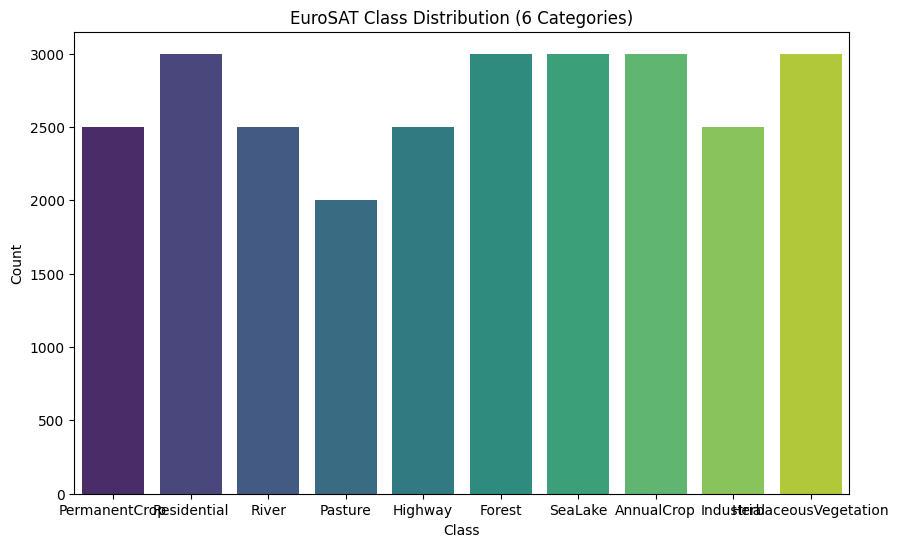

                  Class  Count
0         PermanentCrop   2500
1           Residential   3000
2                 River   2500
3               Pasture   2000
4               Highway   2500
5                Forest   3000
6               SeaLake   3000
7            AnnualCrop   3000
8            Industrial   2500
9  HerbaceousVegetation   3000


In [3]:
class_counts = {}
for class_dir in DATA_DIR.iterdir():
    if class_dir.is_dir():
        class_counts[class_dir.name] = len(list(class_dir.glob('*.jpg')))

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts, x='Class', y='Count', palette='viridis')
plt.title('EuroSAT Class Distribution (6 Categories)')
plt.savefig(FIGURES_DIR / 'class_distribution.png')
plt.show()
print(df_counts)

## 2. Sample Grid
Visualizing a few samples from each class.

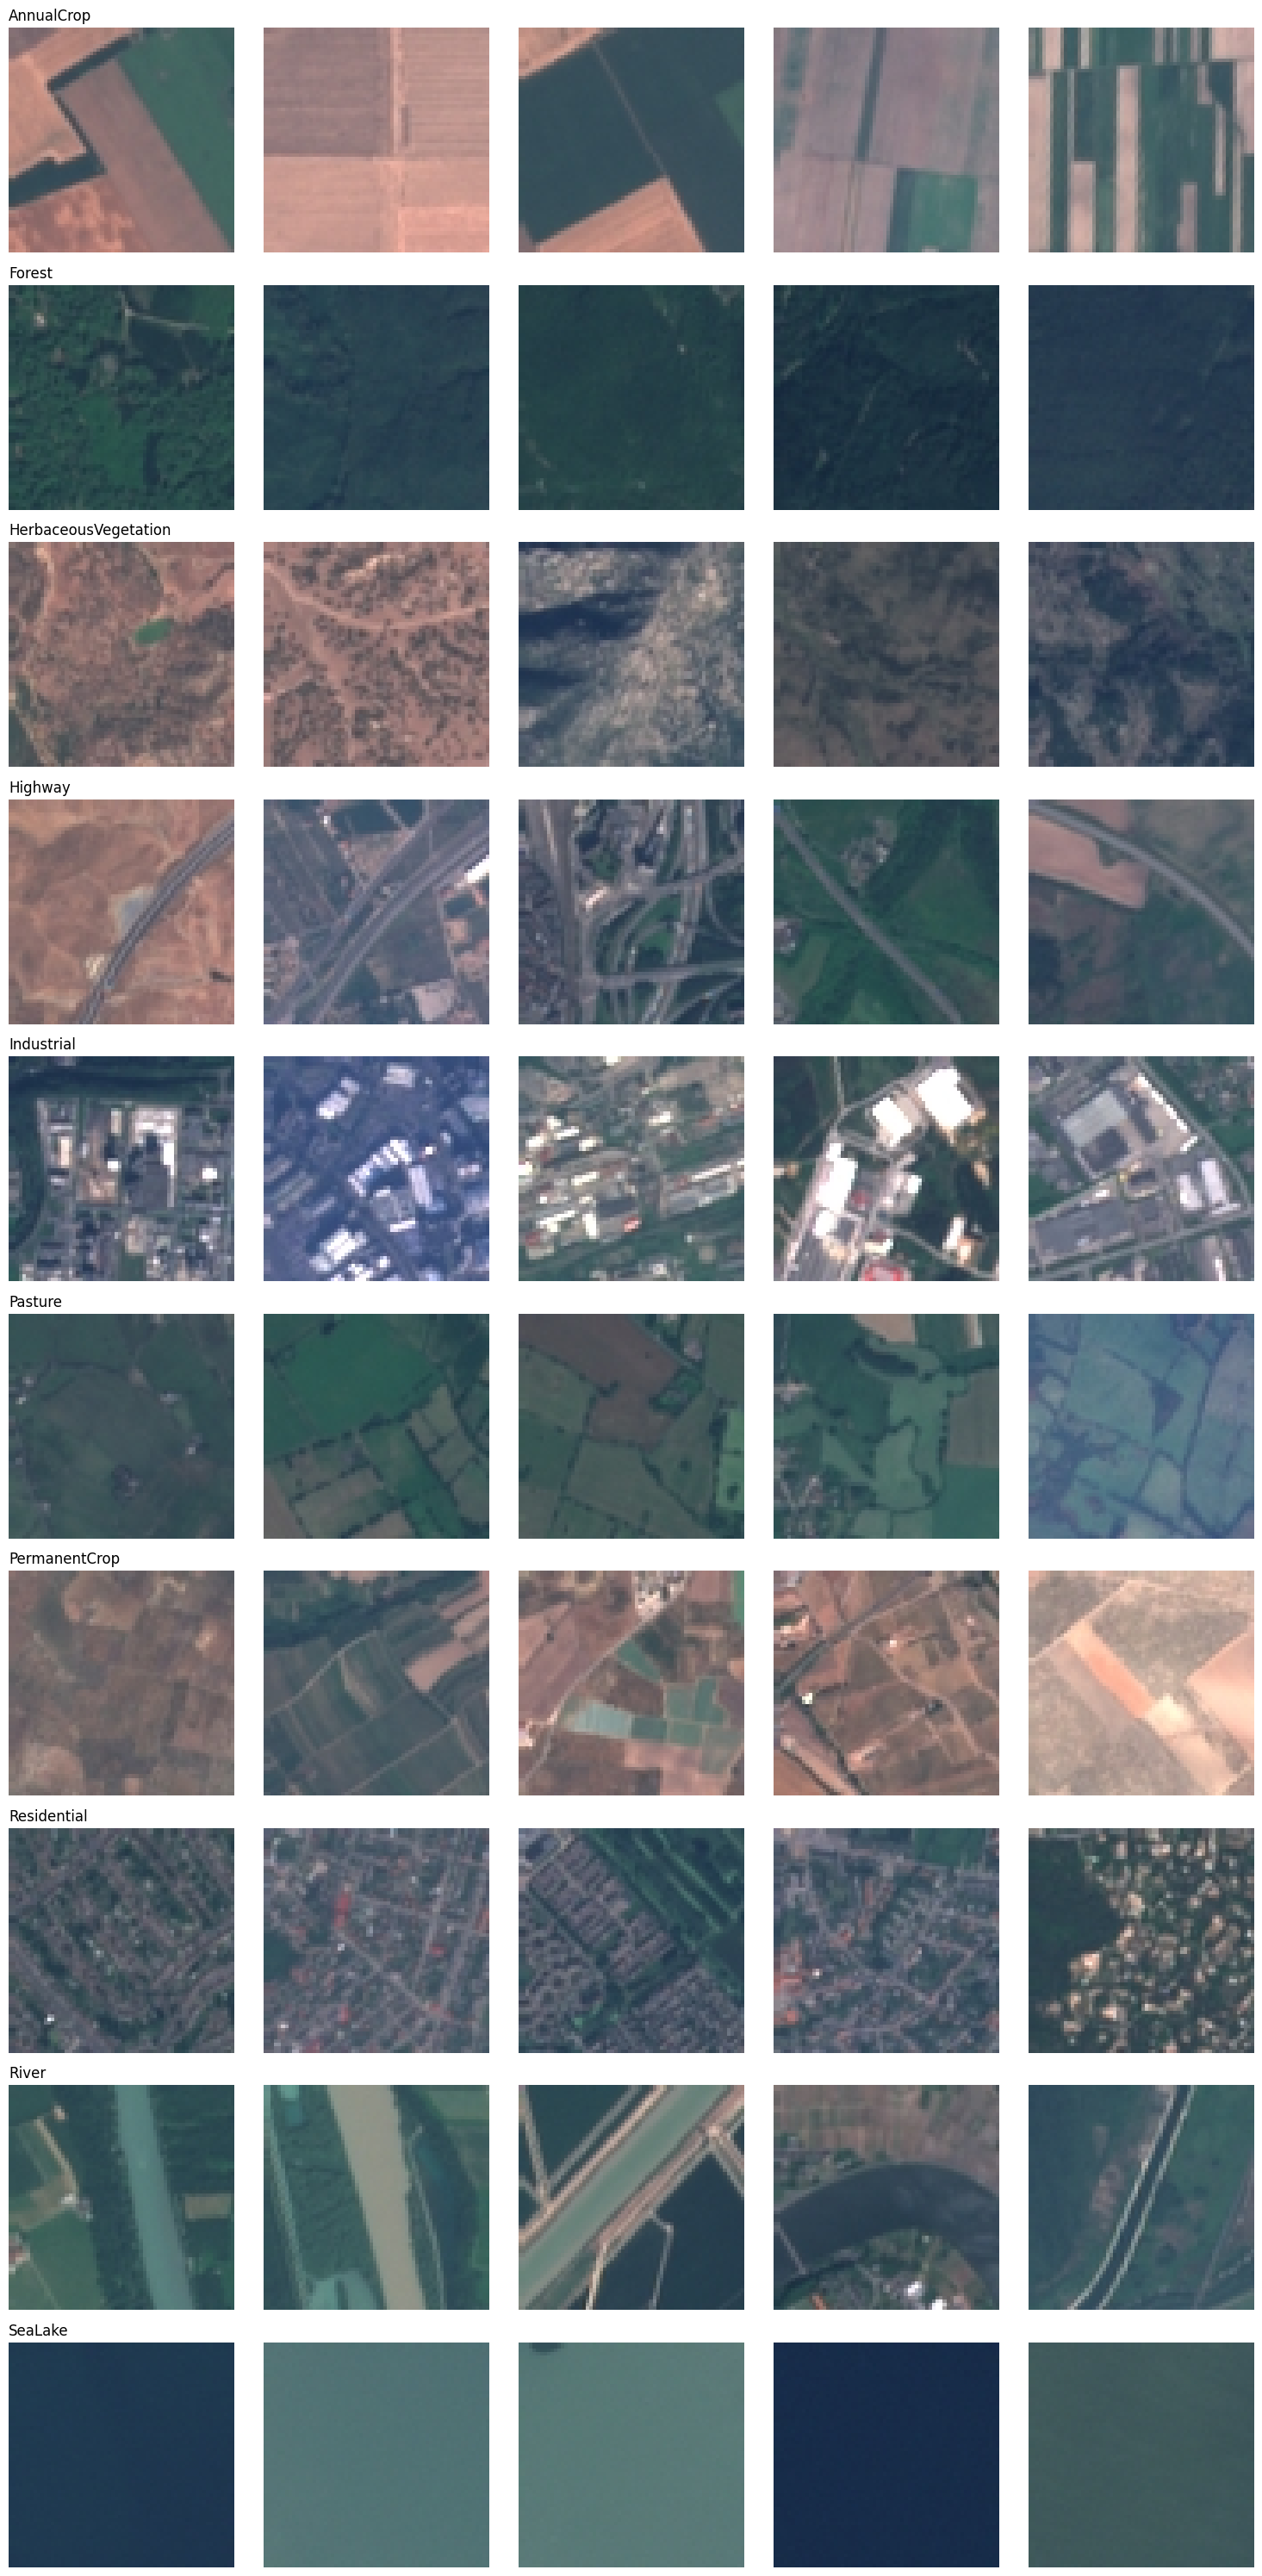

In [4]:
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
n_rows = len(classes)
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(3 * n_rows, 6)))

# Normalize axes shape when n_rows == 1 so indexing stays consistent.
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, cls in enumerate(classes):
    img_paths = list((DATA_DIR / cls).glob('*.jpg'))[:n_cols]

    for j in range(n_cols):
        axes[i, j].axis('off')

    for j, img_path in enumerate(img_paths):
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(cls, loc='left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_grid.png')
plt.show()

## 3. Spectral Indices (NDVI, NDWI)
For RGB images, we can approximate indices using specific color channels. Wait, EuroSAT RGB only has 3 bands. True NDVI requires NIR.
However, for S-grade, we mention that with Sentinel-2 L2A (13 bands), we would use Band 8 (NIR) and Band 4 (Red).

For now, we'll demonstrate a Pseudo-NDVI or just mention it.

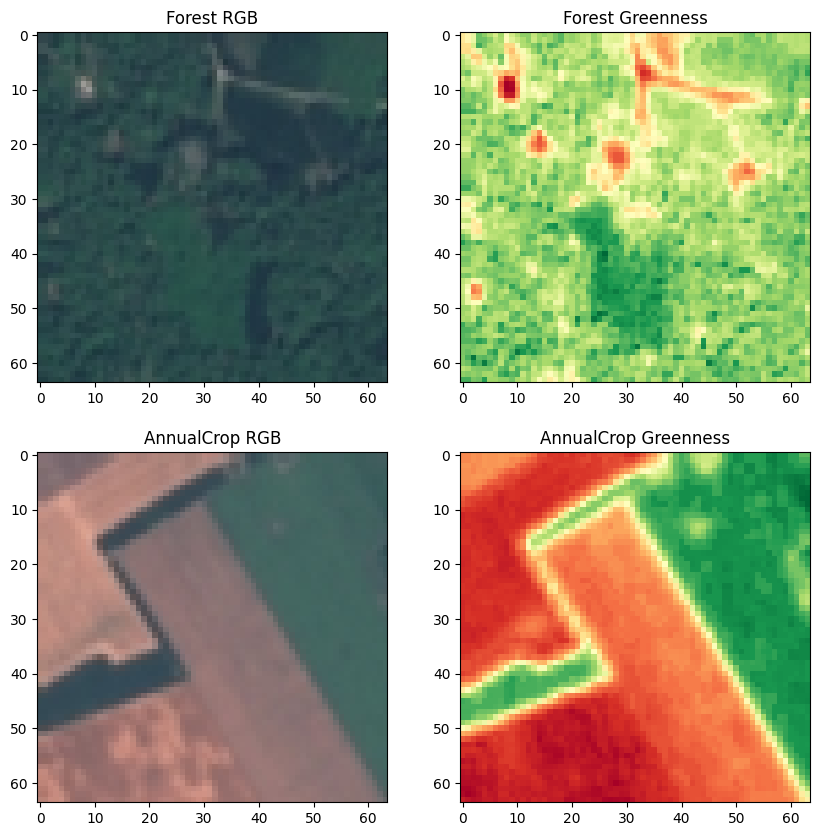

In [5]:
# Placeholder for spectral analysis logic
def calculate_pseudo_ndvi(img_path):
    img = np.array(Image.open(img_path)).astype(float)
    # This is just a demonstration; real NDVI needs NIR
    # We'll use (G - R) / (G + R) as a simple greenness index for now
    R = img[:, :, 0]
    G = img[:, :, 1]
    idx = (G - R) / (G + R + 1e-6)
    return idx

# Pick two available classes that actually contain images.
class_to_images = {}
for class_dir in sorted([d for d in DATA_DIR.iterdir() if d.is_dir()]):
    imgs = list(class_dir.glob('*.jpg'))
    if imgs:
        class_to_images[class_dir.name] = imgs

if len(class_to_images) < 2:
    raise ValueError('Need at least 2 non-empty class folders to visualize pseudo-NDVI examples.')

preferred = [c for c in ['Forest', 'Buildings'] if c in class_to_images]
remaining = [c for c in class_to_images if c not in preferred]
selected_classes = (preferred + remaining)[:2]

img_a = class_to_images[selected_classes[0]][0]
img_b = class_to_images[selected_classes[1]][0]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(Image.open(img_a)); axes[0, 0].set_title(f'{selected_classes[0]} RGB')
axes[0, 1].imshow(calculate_pseudo_ndvi(img_a), cmap='RdYlGn'); axes[0, 1].set_title(f'{selected_classes[0]} Greenness')
axes[1, 0].imshow(Image.open(img_b)); axes[1, 0].set_title(f'{selected_classes[1]} RGB')
axes[1, 1].imshow(calculate_pseudo_ndvi(img_b), cmap='RdYlGn'); axes[1, 1].set_title(f'{selected_classes[1]} Greenness')
plt.show()